SCHWARZSCHILD BLACK HOLE
Black-hole mass = 10.00 solar masses
Gravitational radius = 1.477e+06 cm
Schwarzschild radius = 2.953e+06 cm
ISCO radius = 8.860e+06 cm
ISCO radius = 88.600 km
Eddington luminosity = 1.257e+39 erg/s
Radiative efficiency = 0.057
Accretion rate = 2.454e+18 g/s
Accretion rate = 3.894e-08 solar masses/year

Maximum disk temperature:
T_max = nan K
Radius of T_max = 6.00 r_g

Disk luminosity:
L_disk = 1.806e+38 erg/s
L_disk / L_Edd = 0.144

SAMPLE DISK VALUES
     r/r_g           T [K]      Sigma [g/cm2]        rho [g/cm3]        F [erg/cm2/s]
       6.0             nan                nan                nan           -1.241e+08
      10.0       4.679e+06          6.051e+05          7.767e+00            2.717e+22
      20.0       3.313e+06          6.062e+05          3.278e+00            6.834e+21
      50.0       1.827e+06          4.018e+05          7.399e-01            6.315e+20
      99.8       1.128e+06          2.666e+05          2.215e-01            9.165e+19
 

C:\Users\Amrit\AppData\Local\Temp\ipykernel_12536\3237375643.py:107: RuntimeWarning: invalid value encountered in power
  T_eff = (F / sigma)**0.25


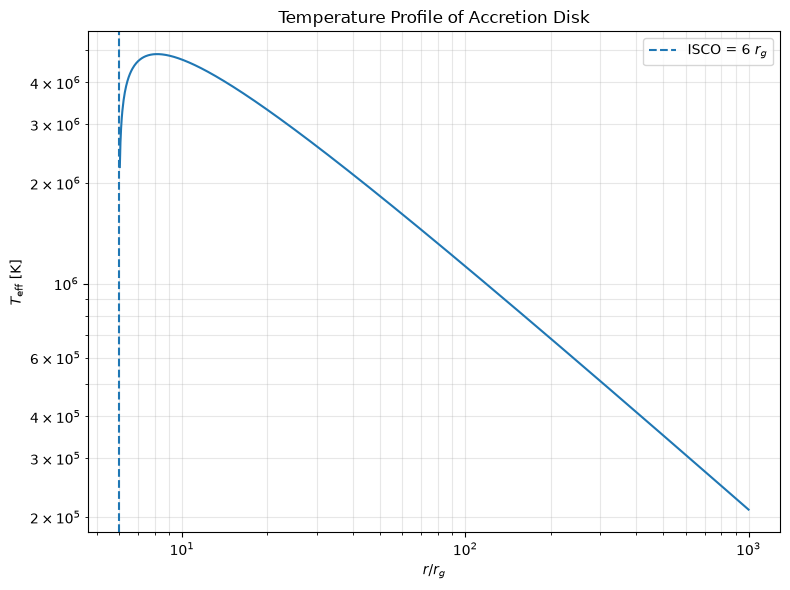

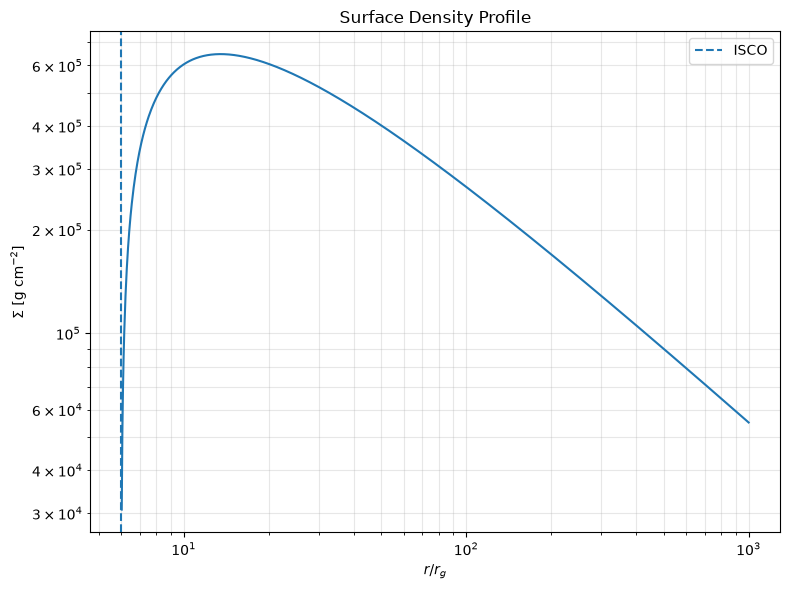

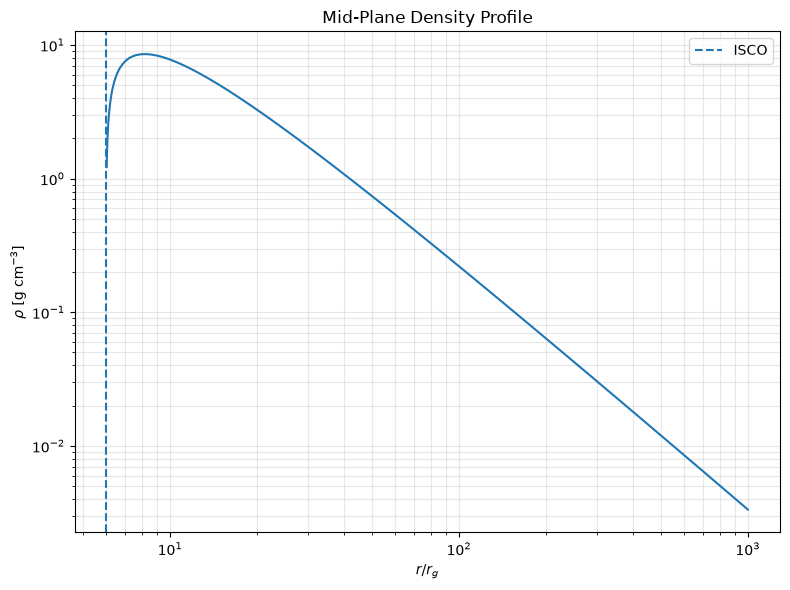

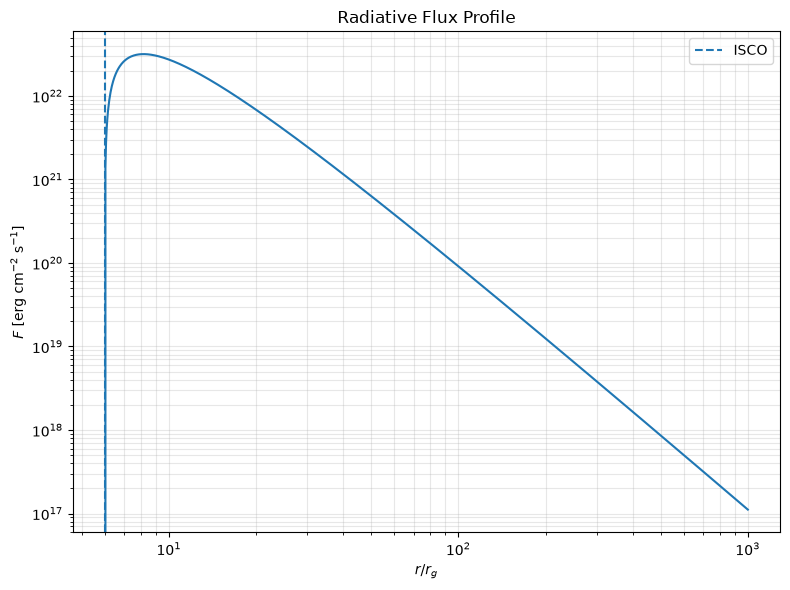

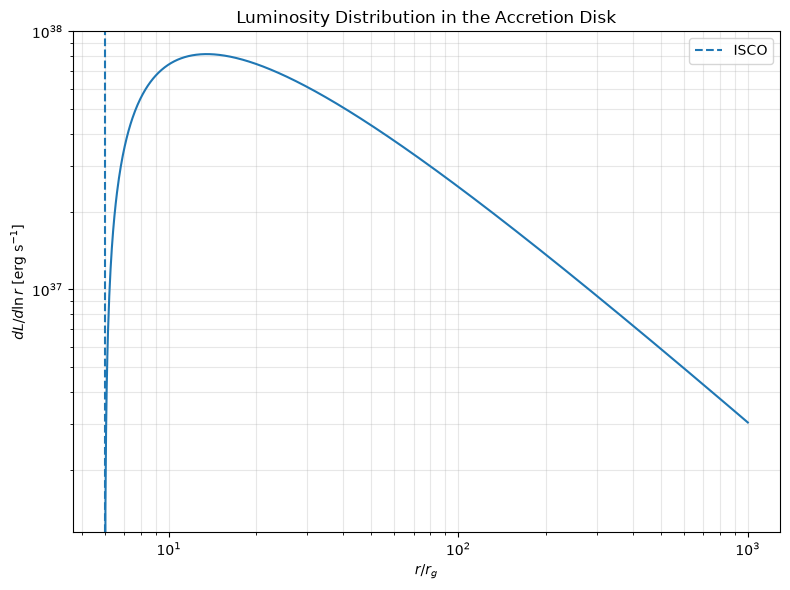

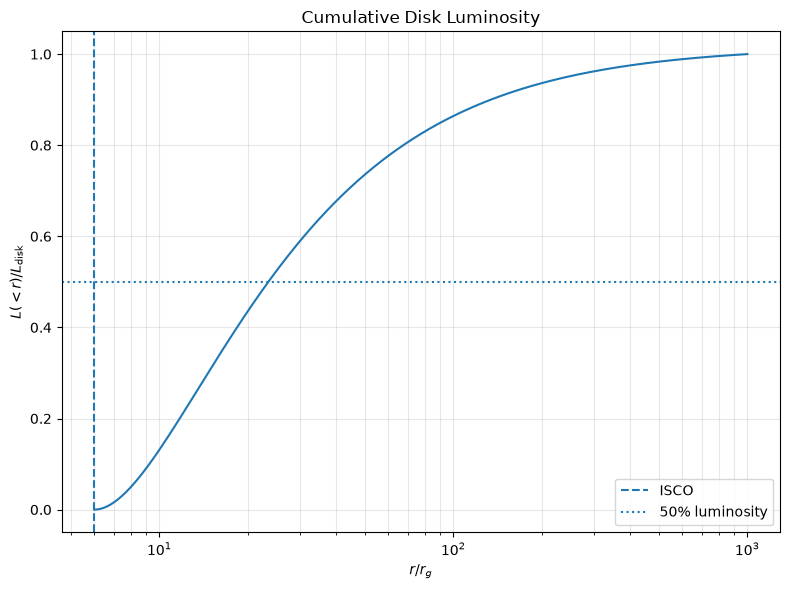


Results saved as:
schwarzschild_accretion_disk_profiles.csv


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ACCRETION DISK AROUND A SCHWARZSCHILD BLACK HOLE
# Shakura-Sunyaev thin disk model
# ============================================================

# ------------------------------------------------------------
# 1. PHYSICAL CONSTANTS (CGS units)
# ------------------------------------------------------------

G = 6.67430e-8          # gravitational constant [cm^3 g^-1 s^-2]
c = 2.99792458e10       # speed of light [cm/s]
sigma = 5.670374419e-5  # Stefan-Boltzmann constant [erg cm^-2 s^-1 K^-4]
k_B = 1.380649e-16      # Boltzmann constant [erg/K]
m_p = 1.67262192369e-24 # proton mass [g]
M_sun = 1.98847e33      # solar mass [g]
sigma_T = 6.6524587158e-25  # Thomson cross section [cm^2]

# Mean molecular weight
mu = 0.62

# ------------------------------------------------------------
# 2. BLACK HOLE PARAMETERS
# ------------------------------------------------------------

M_solar = 10.0                  # black-hole mass [solar masses]
M = M_solar * M_sun             # black-hole mass [g]

# Gravitational radius
r_g = G * M / c**2

# Schwarzschild radius
r_s = 2 * r_g

# ISCO for Schwarzschild black hole
r_isco = 6 * r_g

print("==============================================")
print("SCHWARZSCHILD BLACK HOLE")
print("==============================================")
print(f"Black-hole mass = {M_solar:.2f} solar masses")
print(f"Gravitational radius = {r_g:.3e} cm")
print(f"Schwarzschild radius = {r_s:.3e} cm")
print(f"ISCO radius = {r_isco:.3e} cm")
print(f"ISCO radius = {r_isco/1e5:.3f} km")
print("==============================================")

# ------------------------------------------------------------
# 3. EDDINGTON LUMINOSITY
# ------------------------------------------------------------

L_edd = 4 * np.pi * G * M * m_p * c / sigma_T

print(f"Eddington luminosity = {L_edd:.3e} erg/s")

# ------------------------------------------------------------
# 4. ACCRETION RATE
# ------------------------------------------------------------

# Radiative efficiency for Schwarzschild black hole
eta = 0.057

# Choose accretion rate = 10% Eddington
eddington_fraction = 0.10

Mdot = eddington_fraction * L_edd / (eta * c**2)

print(f"Radiative efficiency = {eta:.3f}")
print(f"Accretion rate = {Mdot:.3e} g/s")
print(f"Accretion rate = {Mdot/M_sun*365.25*24*3600:.3e} solar masses/year")

# ------------------------------------------------------------
# 5. RADIAL GRID
# ------------------------------------------------------------

# Radius from ISCO to 1000 gravitational radii
r = np.logspace(np.log10(6*r_g), np.log10(1000*r_g), 1000)

# Dimensionless radius
R = r / r_g

# ------------------------------------------------------------
# 6. KEPLERIAN ANGULAR VELOCITY
# ------------------------------------------------------------

Omega_K = np.sqrt(G * M / r**3)

# Keplerian velocity
v_K = np.sqrt(G * M / r)

# ------------------------------------------------------------
# 7. STANDARD THIN-DISK RADIATIVE FLUX
# ------------------------------------------------------------

# Zero-torque boundary condition at ISCO
boundary = 1 - np.sqrt(r_isco / r)

# Radiative flux from ONE surface
F = (3 * G * M * Mdot / (8 * np.pi * r**3)) * boundary

# ------------------------------------------------------------
# 8. EFFECTIVE TEMPERATURE
# ------------------------------------------------------------

T_eff = (F / sigma)**0.25

# Find maximum temperature
max_index = np.argmax(T_eff)

print("\nMaximum disk temperature:")
print(f"T_max = {T_eff[max_index]:.3e} K")
print(f"Radius of T_max = {R[max_index]:.2f} r_g")

# ------------------------------------------------------------
# 9. ALPHA DISK MODEL
# ------------------------------------------------------------

alpha = 0.1

# Sound speed approximation
c_s = np.sqrt(k_B * T_eff / (mu * m_p))

# Disk scale height
H = c_s / Omega_K

# Kinematic viscosity
nu = alpha * c_s * H

# ------------------------------------------------------------
# 10. SURFACE DENSITY
# ------------------------------------------------------------

Sigma = (Mdot / (3 * np.pi * nu)) * boundary

# ------------------------------------------------------------
# 11. MID-PLANE DENSITY
# ------------------------------------------------------------

rho = Sigma / (2 * H)

# ------------------------------------------------------------
# 12. DISK LUMINOSITY
# ------------------------------------------------------------

# Luminosity from an annulus:
#
# dL = 2 surfaces * (2*pi*r*dr) * F
#    = 4*pi*r*F*dr

dL_dr = 4 * np.pi * r * F

# Luminosity per logarithmic radius:
#
# dL/dln(r) = r * dL/dr

dL_dlnr = r * dL_dr

# ------------------------------------------------------------
# 13. CUMULATIVE LUMINOSITY
# ------------------------------------------------------------

# Numerical integration
L_cumulative = np.zeros_like(r)

for i in range(1, len(r)):
    dr = r[i] - r[i-1]

    L_cumulative[i] = (
        L_cumulative[i-1]
        + 0.5 * (dL_dr[i] + dL_dr[i-1]) * dr
    )

L_total = L_cumulative[-1]

print("\nDisk luminosity:")
print(f"L_disk = {L_total:.3e} erg/s")
print(f"L_disk / L_Edd = {L_total/L_edd:.3f}")

# ------------------------------------------------------------
# 14. PRINT SOME REPRESENTATIVE VALUES
# ------------------------------------------------------------

print("\n==============================================")
print("SAMPLE DISK VALUES")
print("==============================================")

sample_R = [6, 10, 20, 50, 100, 500, 1000]

print(
    f"{'r/r_g':>10} "
    f"{'T [K]':>15} "
    f"{'Sigma [g/cm2]':>18} "
    f"{'rho [g/cm3]':>18} "
    f"{'F [erg/cm2/s]':>20}"
)

for R_value in sample_R:

    index = np.argmin(np.abs(R - R_value))

    print(
        f"{R[index]:10.1f} "
        f"{T_eff[index]:15.3e} "
        f"{Sigma[index]:18.3e} "
        f"{rho[index]:18.3e} "
        f"{F[index]:20.3e}"
    )

# ============================================================
# 15. PLOT 1: TEMPERATURE PROFILE
# ============================================================

plt.figure(figsize=(8, 6))

plt.loglog(R, T_eff)

plt.xlabel(r"$r/r_g$")
plt.ylabel(r"$T_{\rm eff}$ [K]")
plt.title("Temperature Profile of Accretion Disk")

plt.grid(True, which="both", alpha=0.3)

plt.axvline(
    6,
    linestyle="--",
    label="ISCO = 6 $r_g$"
)

plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 16. PLOT 2: SURFACE DENSITY PROFILE
# ============================================================

plt.figure(figsize=(8, 6))

plt.loglog(R, Sigma)

plt.xlabel(r"$r/r_g$")
plt.ylabel(r"$\Sigma$ [g cm$^{-2}$]")
plt.title("Surface Density Profile")

plt.grid(True, which="both", alpha=0.3)

plt.axvline(
    6,
    linestyle="--",
    label="ISCO"
)

plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 17. PLOT 3: MID-PLANE DENSITY PROFILE
# ============================================================

plt.figure(figsize=(8, 6))

plt.loglog(R, rho)

plt.xlabel(r"$r/r_g$")
plt.ylabel(r"$\rho$ [g cm$^{-3}$]")
plt.title("Mid-Plane Density Profile")

plt.grid(True, which="both", alpha=0.3)

plt.axvline(
    6,
    linestyle="--",
    label="ISCO"
)

plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 18. PLOT 4: RADIATIVE FLUX PROFILE
# ============================================================

plt.figure(figsize=(8, 6))

plt.loglog(R, F)

plt.xlabel(r"$r/r_g$")
plt.ylabel(r"$F$ [erg cm$^{-2}$ s$^{-1}$]")
plt.title("Radiative Flux Profile")

plt.grid(True, which="both", alpha=0.3)

plt.axvline(
    6,
    linestyle="--",
    label="ISCO"
)

plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 19. PLOT 5: LUMINOSITY PER LOGARITHMIC RADIUS
# ============================================================

plt.figure(figsize=(8, 6))

plt.loglog(R, dL_dlnr)

plt.xlabel(r"$r/r_g$")
plt.ylabel(r"$dL/d\ln r$ [erg s$^{-1}$]")
plt.title("Luminosity Distribution in the Accretion Disk")

plt.grid(True, which="both", alpha=0.3)

plt.axvline(
    6,
    linestyle="--",
    label="ISCO"
)

plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 20. PLOT 6: CUMULATIVE LUMINOSITY
# ============================================================

plt.figure(figsize=(8, 6))

plt.semilogx(R, L_cumulative / L_total)

plt.xlabel(r"$r/r_g$")
plt.ylabel(r"$L(<r)/L_{\rm disk}$")
plt.title("Cumulative Disk Luminosity")

plt.grid(True, which="both", alpha=0.3)

plt.axvline(
    6,
    linestyle="--",
    label="ISCO"
)

plt.axhline(
    0.5,
    linestyle=":",
    label="50% luminosity"
)

plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 21. SAVE RESULTS TO CSV
# ============================================================

import pandas as pd

data = pd.DataFrame({
    "r_cm": r,
    "r_over_rg": R,
    "Omega_K": Omega_K,
    "H_cm": H,
    "Sigma_g_cm2": Sigma,
    "rho_g_cm3": rho,
    "F_erg_cm2_s": F,
    "T_eff_K": T_eff,
    "dL_dr": dL_dr,
    "dL_dlnr": dL_dlnr,
    "L_cumulative_erg_s": L_cumulative
})

data.to_csv(
    "schwarzschild_accretion_disk_profiles.csv",
    index=False
)

print("\nResults saved as:")
print("schwarzschild_accretion_disk_profiles.csv")

In [6]:
import numpy as np
import pandas as pd

# ============================================================
# CONSTANTS
# ============================================================

G = 6.67430e-8
c = 2.99792458e10
sigma = 5.670374419e-5
k_B = 1.380649e-16
m_p = 1.67262192369e-24
sigma_T = 6.6524587158e-25
M_sun = 1.98847e33

# ============================================================
# BLACK HOLE PARAMETERS
# ============================================================

M_solar = 10.0
M = M_solar * M_sun

# Gravitational radius
rg = G * M / c**2

# Schwarzschild ISCO
r_isco = 6 * rg

# ============================================================
# EDDINGTON ACCRETION RATE
# ============================================================

L_edd = 4 * np.pi * G * M * m_p * c / sigma_T

eta = 0.057

# 10% Eddington accretion
Mdot = 0.10 * L_edd / (eta * c**2)

# ============================================================
# RADIAL GRID
# ============================================================

r = np.logspace(
    np.log10(r_isco),
    np.log10(1000 * rg),
    1000
)

R = r / rg

# ============================================================
# KEPLERIAN ANGULAR VELOCITY
# ============================================================

Omega = np.sqrt(G * M / r**3)

# ============================================================
# DISK FLUX
# ============================================================

boundary = 1 - np.sqrt(r_isco / r)

F = (
    3 * G * M * Mdot
    / (8 * np.pi * r**3)
) * boundary

# ============================================================
# TEMPERATURE
# ============================================================

T = (F / sigma)**0.25

# ============================================================
# SOUND SPEED
# ============================================================

mu = 0.62

cs = np.sqrt(
    k_B * T / (mu * m_p)
)

# ============================================================
# DISK HEIGHT
# ============================================================

H = cs / Omega

# ============================================================
# ALPHA VISCOSITY
# ============================================================

alpha = 0.1

nu = alpha * cs * H

# ============================================================
# SURFACE DENSITY
# ============================================================

Sigma = (
    Mdot / (3 * np.pi * nu)
) * boundary

# ============================================================
# MID-PLANE DENSITY
# ============================================================

rho = Sigma / (2 * H)

# ============================================================
# LUMINOSITY PER UNIT RADIUS
# ============================================================

dL_dr = 4 * np.pi * r * F

# ============================================================
# CUMULATIVE LUMINOSITY
# ============================================================

from scipy.integrate import cumulative_trapezoid

L = cumulative_trapezoid(
    dL_dr,
    r,
    initial=0
)

# ============================================================
# CREATE DATA TABLE
# ============================================================

data = pd.DataFrame({
    "radius_rg": R,
    "radius_cm": r,
    "temperature_K": T,
    "surface_density_g_cm2": Sigma,
    "midplane_density_g_cm3": rho,
    "flux_erg_cm2_s": F,
    "luminosity_per_radius": dL_dr,
    "cumulative_luminosity": L
})

# ============================================================
# SAVE CSV
# ============================================================

data.to_csv(
    "accretion_disk_data.csv",
    index=False
)

print("Calculation completed successfully!")
print()
print("Number of radial points:", len(data))
print()
print(data.head())
print()
print("CSV saved as: accretion_disk_data.csv")

C:\Users\Amrit\AppData\Local\Temp\ipykernel_12536\751491647.py:73: RuntimeWarning: invalid value encountered in power
  T = (F / sigma)**0.25


Calculation completed successfully!

Number of radial points: 1000

   radius_rg     radius_cm  temperature_K  surface_density_g_cm2  \
0   6.000000  8.860018e+06            NaN                    NaN   
1   6.030806  8.905508e+06   2.232096e+06           30713.543689   
2   6.061769  8.951231e+06   2.643404e+06           51406.451121   
3   6.092892  8.997189e+06   2.913261e+06           69342.811165   
4   6.124174  9.043383e+06   3.117505e+06           85629.035263   

   midplane_density_g_cm3  flux_erg_cm2_s  luminosity_per_radius  \
0                     NaN   -1.241073e+08          -1.381789e+16   
1                1.221155    1.407549e+21           1.575187e+29   
2                1.863791    2.768635e+21           3.114285e+29   
3                2.376495    4.084410e+21           4.617916e+29   
4                2.815183    5.356001e+21           6.086693e+29   

   cumulative_luminosity  
0           0.000000e+00  
1           3.582729e+33  
2           1.430359e+34  
3     